In [17]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import math

from pyro_cases.run import vae_dict
from pyro_cases.run_non_amoretized_vae import train_and_test_non_amortized_vae

In [18]:
device = torch.device("cuda:1")

In [19]:
out_dict = train_and_test_non_amortized_vae(task_name="two_moons",
                                            seed=126,
                                            device=device,
                                            lr=1e-3,
                                            num_particles=1,
                                            vectorize_particles=False,
                                            steps=10_000,
                                            test_seed=7272,
                                            num_test_obs=1000,
                                            show_progress=True,
                                            return_vae=True,
                                            suppress_error=False)

100%|██████████| 10000/10000 [01:48<00:00, 92.51it/s]

[task two_moons seed 126 completes] task start time: Sun Jul  6 17:15:32 2025; task end time: Sun Jul  6 17:17:20 2025; cost time: 108.1 seconds


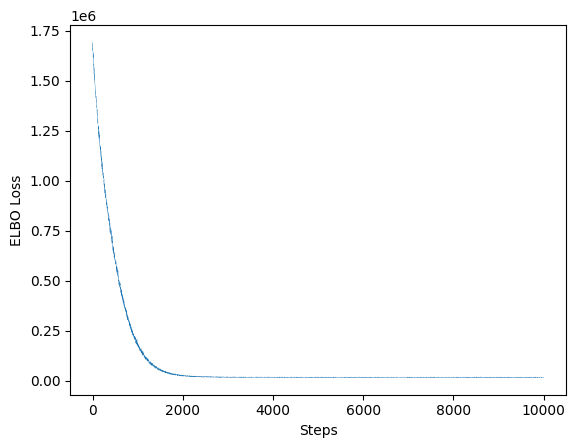

In [20]:
plt.plot(out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.show()

### VSBC

In [ ]:
elbo_vsbc = out_dict["elbo_vsbc"]

In [ ]:
def plot_vsbc(vsbc_matrix: torch.Tensor):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.tight_layout()
    fig.show()

In [ ]:
plot_vsbc(elbo_vsbc)

### Output

In [21]:
out_dict.keys()

dict_keys(['seed', 'task', 'elbo_training_loss', 'elbo_test_dict_list', 'elbo_vae', 'elbo_vsbc', 'elbo_error'])

In [22]:
out_dict["elbo_test_dict_list"].keys()

dict_keys(['obs_seed', 'obs', 'est_sigma2', 'est_mu', 'true_theta'])

In [23]:
out_dict["elbo_test_dict_list"]["obs"].shape

torch.Size([1000, 2])

In [24]:
out_dict["elbo_test_dict_list"]["obs"][:5]

tensor([[ 0.2352,  0.3558],
        [-0.2672,  0.3102],
        [ 0.2556,  0.0667],
        [ 0.3287, -0.1272],
        [-0.0231,  0.0849]])

In [25]:
out_dict["elbo_test_dict_list"]["true_theta"][:5]

tensor([[-0.1434,  0.2772],
        [ 0.2244,  0.5514],
        [-0.1385, -0.0052],
        [ 0.1228, -0.1226],
        [-0.3159, -0.2357]])

In [26]:
out_dict["elbo_test_dict_list"]["est_mu"][:5]

tensor([[-0.2490,  0.2518],
        [-0.5849, -0.1426],
        [-0.0424,  0.0480],
        [ 0.0904, -0.0864],
        [ 0.1358,  0.2481]])

In [27]:
out_dict["elbo_test_dict_list"]["est_sigma2"][:5]

tensor([[0.0100, 0.0090],
        [0.0098, 0.0081],
        [0.0083, 0.0078],
        [0.0018, 0.0018],
        [0.0086, 0.0085]])

In [28]:
def two_moon_posterior(x: torch.Tensor, theta: torch.Tensor):
    assert x.ndim == 1 and x.shape[0] == 2
    assert theta.ndim == 2 and theta.shape[1] == 2
    r_cos_alpha = x[0] + theta.sum(dim=-1).abs() / math.sqrt(2) - 0.25
    r_sin_alpha = x[1] + (theta[:, 0] - theta[:, 1]) / math.sqrt(2)
    r = (r_cos_alpha ** 2 + r_sin_alpha ** 2).sqrt()
    post_log_prob = torch.distributions.Normal(torch.ones_like(r) * 0.1, torch.ones_like(r) * 0.01).log_prob(r)
    return torch.where(r_cos_alpha < 0.0, -torch.inf, post_log_prob)

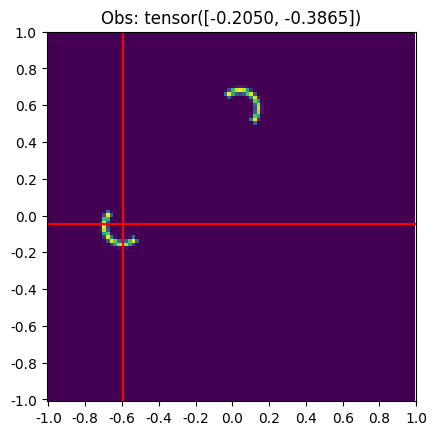

In [29]:
test_i = 139
theta_mesh = torch.stack(torch.meshgrid(torch.linspace(-1, 1, 100),
                                        torch.linspace(-1, 1, 100),
                                        indexing="ij"), dim=-1).view(-1, 2)  # (100 x 100, 2)
obs = out_dict["elbo_test_dict_list"]["obs"][test_i]
theta_log_prob = two_moon_posterior(obs, theta_mesh)
theta_prob = torch.exp(theta_log_prob).view(100, 100)

pred_theta_loc = out_dict["elbo_test_dict_list"]["est_mu"][test_i]
pred_theta_scale = out_dict["elbo_test_dict_list"]["est_sigma2"][test_i]

plt.imshow(theta_prob, origin="lower")
plt.xticks(range(0, 101, 10), [f"{(i / 50 - 1):.1f}" for i in range(0, 101, 10)])
plt.yticks(range(0, 101, 10), [f"{(i / 50 - 1):.1f}" for i in range(0, 101, 10)])
plt.axvline(x=(pred_theta_loc[1] + 1) / 2 * 100, color="red")
plt.axhline(y=(pred_theta_loc[0] + 1) / 2 * 100, color="red")
plt.title(f"Obs: {obs}")
plt.show()

### Smoke Test

In [ ]:
for i, task_name in enumerate(vae_dict.keys()):
    print(f"[{i}] run task {task_name}")
    try:
        out_dict = train_and_test_non_amortized_vae(task_name=task_name,
                                                    seed=123456,
                                                    device=device,
                                                    lr=1e-3,
                                                    num_particles=1,
                                                    vectorize_particles=False,
                                                    steps=10,
                                                    test_seed=7272,
                                                    num_test_obs=1000,
                                                    show_progress=False,
                                                    silent=False,
                                                    return_vae=True,
                                                    suppress_error=False)
    except Exception as e:
        print(f"Get Error: {str(e)}")
    else:
        print(f"[{i}] task {task_name} passes")
    print()